# Lab 09：Flow Matching 與 Rectified Flow（2D）

對應講義：[第 09 課](../lessons/09_flow_matching.md)

時間方向：**$t = 0$ 是雜訊、$t = 1$ 是資料**。

1. 用 conditional flow matching（式 9.4）訓練一個速度場
2. Euler 法走 1、2、5、20、100 步：品質怎麼變？
3. 訓練用的是直線，生成的路徑卻是彎的——畫出來看
4. 和 DDPM＋DDIM 在相同步數下比較
5. Reflow：把路徑拉直，讓 1–2 步就能生成

CPU 約 5 分鐘。

In [1]:
import matplotlib.pyplot as plt
import torch

from diffusion_course.utils import get_device, notebook_logging, set_seed

%matplotlib inline
plt.rcParams["figure.dpi"] = 80
notebook_logging()
set_seed(0)
device = get_device()
print(f"torch {torch.__version__} on {device}")

torch 2.14.0+cpu on cpu


## 0. 一個量化指標：sliced Wasserstein distance

2D 樣本好不好，除了用看的，也用一個簡單的距離量：把兩組點投影到很多個隨機方向上，比較投影後的一維分布（排序後逐點相減）。越小越好。

In [2]:
from diffusion_course.data import make_toy_data, toy_batches
from diffusion_course.viz import new_axes, plot_points, plot_trajectories

DATASET = "moons"
TRAIN_STEPS = 5000
reference = make_toy_data(DATASET, 20_000)


def sliced_wasserstein(a: torch.Tensor, b: torch.Tensor, num_directions: int = 200) -> float:
    n = min(len(a), len(b))
    directions = torch.nn.functional.normalize(torch.randn(num_directions, 2), dim=1)
    pa = (a[:n] @ directions.T).sort(dim=0).values
    pb = (b[:n] @ directions.T).sort(dim=0).values
    return (pa - pb).abs().mean().item()


print(f"two independent draws of real data: {sliced_wasserstein(make_toy_data(DATASET, 5000), reference[:5000]):.3f}")

two independent draws of real data: 0.023


## 1. 訓練：三行的損失

In [3]:
import inspect

from diffusion_course.flow_matching import flow_matching_loss, flow_sample
from diffusion_course.models import ToyMLP
from diffusion_course.training import train

print(inspect.getsource(flow_matching_loss).split('"""')[-1])

model = ToyMLP()
result = train(model, lambda m, x, y: flow_matching_loss(m, x), toy_batches(DATASET, 512), TRAIN_STEPS, lr=1e-3, log_every=1000)
flow_model = result.sampling_model
print(f"trained in {result.seconds:.0f}s")


    noise = torch.randn_like(data) if noise is None else noise
    t = torch.rand(data.shape[0], device=data.device)
    x_t = interpolate(noise, data, t)
    return F.mse_loss(model(x_t, t, y), data - noise)



step 1000/5000  loss 1.4460


step 2000/5000  loss 1.4077


step 3000/5000  loss 1.4079


step 4000/5000  loss 1.4010


step 5000/5000  loss 1.3955


trained in 67s


## 2. Euler 步數 vs. 品質

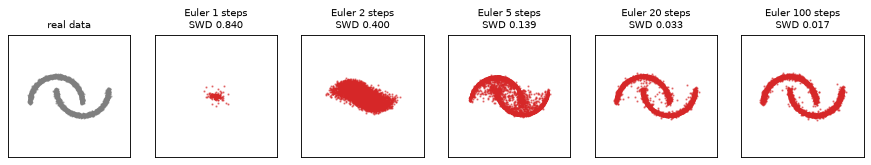

In [4]:
noise = torch.randn(5000, 2)
step_counts = [1, 2, 5, 20, 100]
axes = new_axes(len(step_counts) + 1, size=2.3)
plot_points(reference[:5000], axes[0], "real data", color="tab:gray")
for ax, steps in zip(axes[1:], step_counts):
    samples = flow_sample(flow_model, noise.shape, num_steps=steps, noise=noise)
    plot_points(samples, ax, f"Euler {steps} steps\nSWD {sliced_wasserstein(samples, reference):.3f}", color="tab:red")
plt.show()

## 3. 直線訓練，彎曲生成

左：訓練時用的「條件路徑」——隨機配對的雜訊與資料，用直線相連（大量交叉）。
右：學到的速度場實際走出來的路徑（100 步 Euler）——不交叉，而且是彎的。

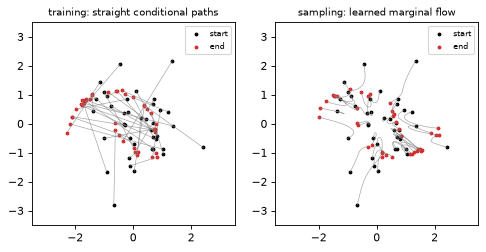

flow matching: total path length / total endpoint distance = 1.623


In [5]:
pairs_noise, pairs_data = torch.randn(40, 2), make_toy_data(DATASET, 40)
straight = torch.stack([pairs_noise + (pairs_data - pairs_noise) * t for t in torch.linspace(0, 1, 20)])
_, learned_paths = flow_sample(flow_model, (40, 2), num_steps=100, noise=pairs_noise, return_trajectory=True)

axes = new_axes(2, size=3.6)
plot_trajectories(straight, axes[0], num_paths=40)
axes[0].set_title("training: straight conditional paths", fontsize=9)
plot_trajectories(learned_paths, axes[1], num_paths=40)
axes[1].set_title("sampling: learned marginal flow", fontsize=9)
plt.show()


def straightness(paths: torch.Tensor) -> float:
    """Total path length over total endpoint distance: 1.0 means perfectly straight.

    A ratio of sums, not a mean of per-path ratios: a particle that starts right next to
    where it ends has a near-zero chord, and its ratio would swamp the average.
    """
    length = (paths[1:] - paths[:-1]).norm(dim=2).sum(dim=0)
    chord = (paths[-1] - paths[0]).norm(dim=1)
    return (length.sum() / chord.sum()).item()


_, many_paths = flow_sample(flow_model, (2000, 2), num_steps=100, return_trajectory=True)
print(f"flow matching: total path length / total endpoint distance = {straightness(many_paths):.3f}")

## 4. 和 DDPM 比較

同樣的網路、同樣的訓練步數，改用 DDPM 的損失訓練，然後用 DDIM 在相同步數下取樣。
兩者都是「解一條 ODE」，差別只在雜訊排程與預測目標（講義 §2.6）。預期：步數多時兩者接近；步數少時，路徑較直的一方離散化誤差較小。

In [6]:
from diffusion_course.ddim import ddim_sample
from diffusion_course.ddpm import ddpm_loss
from diffusion_course.schedules import NoiseSchedule

schedule = NoiseSchedule.create("linear", 1000)
ddpm_model = ToyMLP()
ddpm_result = train(ddpm_model, lambda m, x, y: ddpm_loss(m, schedule, x), toy_batches(DATASET, 512), TRAIN_STEPS, lr=1e-3, log_every=0)

print(f"{'steps':>6}{'flow matching (Euler)':>24}{'DDPM model (DDIM)':>20}")
for steps in [2, 5, 10, 20, 50]:
    fm = flow_sample(flow_model, noise.shape, num_steps=steps, noise=noise)
    dd = ddim_sample(ddpm_result.sampling_model, schedule, noise.shape, num_steps=steps, noise=noise)
    print(f"{steps:>6}{sliced_wasserstein(fm, reference):>24.3f}{sliced_wasserstein(dd, reference):>20.3f}")

 steps   flow matching (Euler)   DDPM model (DDIM)
     2                   0.399               1.358


     5                   0.141               0.224


    10                   0.065               0.098


    20                   0.031               0.040


    50                   0.018               0.035


## 5. Reflow：把路徑拉直

1. 用訓練好的模型，把 5 萬個雜訊點 $z_0$ 用 100 步 Euler 送到 $z_1$，得到**有關聯的配對** $(z_0, z_1)$。
2. 從原模型的權重出發，用同一個直線損失、但**固定這些配對**再訓練（`flow_matching_loss(..., noise=z0)`）。

In [7]:
import copy

NUM_PAIRS = 50_000
REFLOW_STEPS = 3000

z0 = torch.randn(NUM_PAIRS, 2)
z1 = flow_sample(flow_model, z0.shape, num_steps=100, noise=z0)


def paired_batches(batch_size: int = 512):
    while True:
        idx = torch.randint(0, NUM_PAIRS, (batch_size,))
        yield torch.cat([z0[idx], z1[idx]], dim=1), None


reflow_model = copy.deepcopy(flow_model).requires_grad_(True)  # the EMA copy is frozen
reflow_result = train(
    reflow_model,
    lambda m, x, y: flow_matching_loss(m, data=x[:, 2:], noise=x[:, :2]),
    paired_batches(),
    REFLOW_STEPS,
    lr=5e-4,
    log_every=1000,
)
rectified = reflow_result.sampling_model

_, reflow_paths = flow_sample(rectified, (2000, 2), num_steps=100, return_trajectory=True)
print(f"total path length / total endpoint distance: before reflow {straightness(many_paths):.3f}   after reflow {straightness(reflow_paths):.3f}")

step 1000/3000  loss 0.0043


step 2000/3000  loss 0.0004


step 3000/3000  loss 0.0003


total path length / total endpoint distance: before reflow 1.623   after reflow 1.000


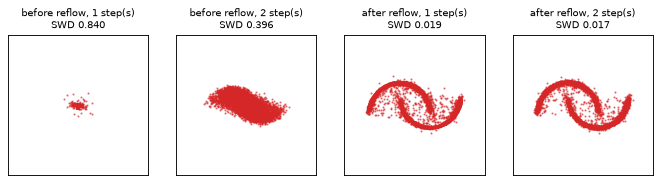

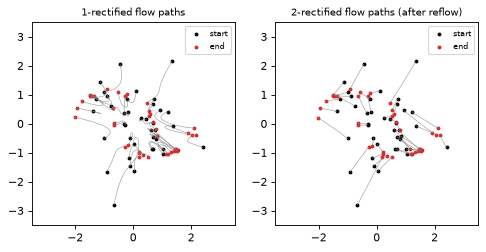

In [8]:
axes = new_axes(4, size=2.6)
for col, (name, m) in enumerate([("before reflow", flow_model), ("after reflow", rectified)]):
    for row, steps in enumerate([1, 2]):
        samples = flow_sample(m, noise.shape, num_steps=steps, noise=noise)
        plot_points(samples, axes[2 * col + row], f"{name}, {steps} step(s)\nSWD {sliced_wasserstein(samples, reference):.3f}", color="tab:red")
plt.show()

_, rectified_paths = flow_sample(rectified, (40, 2), num_steps=100, noise=pairs_noise, return_trajectory=True)
axes = new_axes(2, size=3.6)
plot_trajectories(learned_paths, axes[0], num_paths=40)
axes[0].set_title("1-rectified flow paths", fontsize=9)
plot_trajectories(rectified_paths, axes[1], num_paths=40)
axes[1].set_title("2-rectified flow paths (after reflow)", fontsize=9)
plt.show()

## 小結

- Flow matching 的訓練：直線插值、回歸速度 $x_1 - x_0$，三行。
- 訓練用的直線會交叉，學到的流是它們的平均，所以生成路徑彎曲；步數少時就有誤差。
- 步數多時，flow matching 與 DDPM＋DDIM 的表現接近——它們本來就是同一家人；步數少時 flow matching 明顯較好（直線路徑的離散化誤差較小，講義 §2.6）。
- Reflow 用模型自己產生的配對重新訓練，路徑明顯變直，1–2 步的生成品質大幅改善。

下一課把 flow matching、CFG 與 Transformer 放在一起，在 MNIST 上訓練一個小型 DiT。